# Analyse des variables quantitatives continues

## Bibliothèques importés

In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Fonction connection BDD

In [4]:
def getBDD():
    try:
        bdd = mysql.connector.connect(
            host='localhost',
            database='gamesale',
            user='root',
            password='',
            charset='utf8'
        )
        return bdd
    except Exception as e:
        print("Connection Error: " + str(e))
        return None

## Fonction pour l'analyse des ventes

In [9]:
def graph_ventes(column_name):
    connect = getBDD()
    sql = f"SELECT {column_name} FROM jeux"
    df = pd.read_sql(sql, connect)
    connect.close()

    df[column_name] = df[column_name].astype(str).str.replace(',', '.')
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    df = df.dropna(subset=[column_name])

    plt.figure(figsize=(10, 5))
    ax = sns.histplot(data=df, x=column_name, kde=False, color='skyblue')
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(x = p.get_x() + p.get_width()/2,
                    y = height + 1,
                    s = int(height),
                    ha = 'center')
    plt.title(f'Histogramme de {column_name}')
    plt.ylabel('Nombre de jeux')
    plt.xlabel('Valeur en millions')
    plt.show()

    return df

## Ventes Global

C:\Users\Ica\AppData\Local\Temp\ipykernel_19628\530481841.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


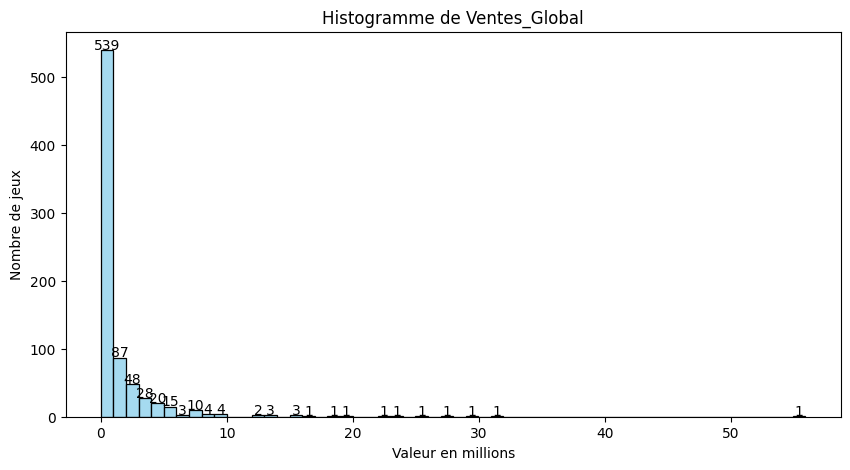

,Ventes_Global
0,55.92
1,23.86
2,16.19
3,31.03
4,29.72
...,...
771,0.01
772,0.01
773,0.01
774,0.01


In [10]:
graph_ventes('Ventes_Global')

## Ventes en Amérique du Nord

C:\Users\Ica\AppData\Local\Temp\ipykernel_19628\530481841.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


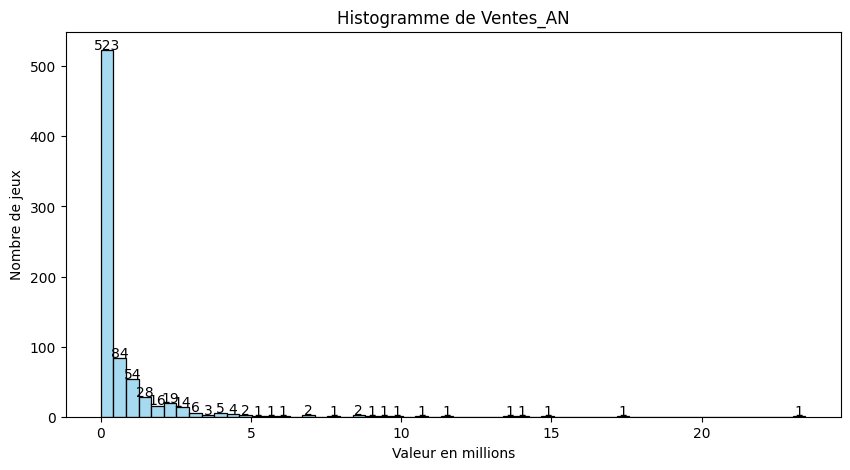

,Ventes_AN
0,23.46
1,10.77
2,8.41
3,17.59
4,14.08
...,...
771,0.00
772,0.00
773,0.00
774,0.00


In [11]:
graph_ventes('Ventes_AN')

## Ventes en Europe

C:\Users\Ica\AppData\Local\Temp\ipykernel_19628\530481841.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


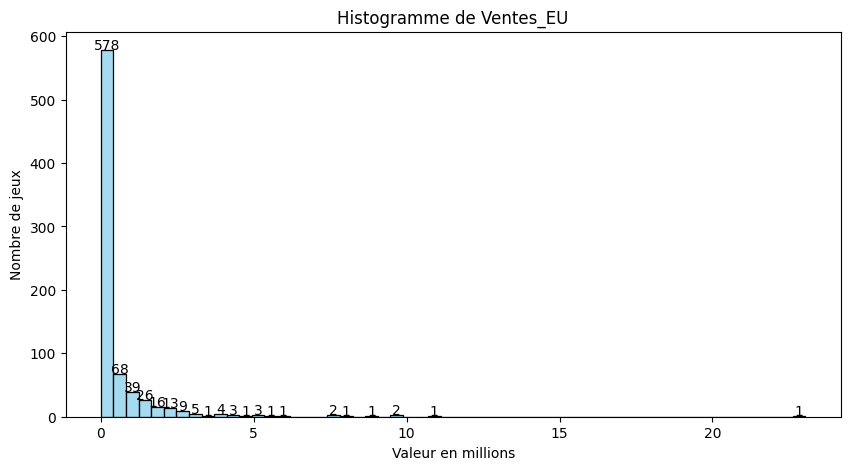

,Ventes_EU
0,23.04
1,1.96
2,5.52
3,9.50
4,11.05
...,...
771,0.01
772,0.01
773,0.01
774,0.01


In [12]:
graph_ventes('Ventes_EU')

## Ventes au Japon

C:\Users\Ica\AppData\Local\Temp\ipykernel_19628\530481841.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


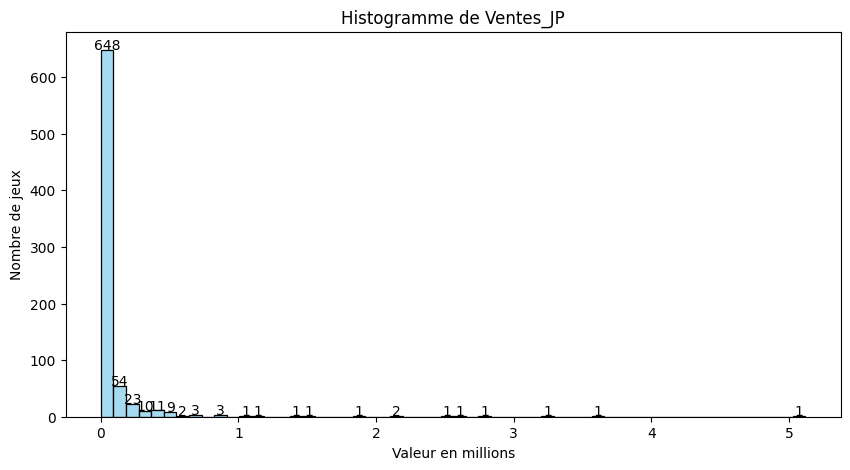

,Ventes_JP
0,1.39
1,0.41
2,0.47
3,0.59
4,0.72
...,...
771,0.00
772,0.00
773,0.00
774,0.00


In [13]:
graph_ventes('Ventes_JP')

## Autres ventes

C:\Users\Ica\AppData\Local\Temp\ipykernel_19628\530481841.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


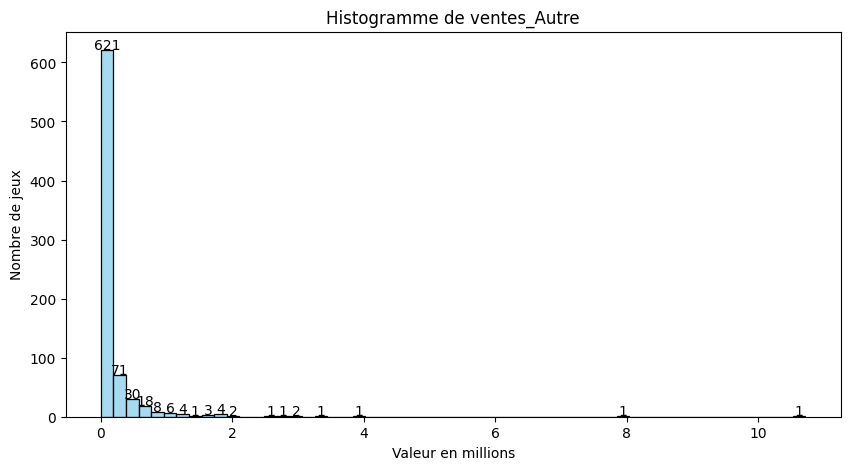

,ventes_Autre
0,8.03
1,10.72
2,1.79
3,3.36
4,3.88
...,...
771,0.00
772,0.00
773,0.00
774,0.00


In [14]:
graph_ventes('ventes_Autre')

## Fonction pour le prix

In [7]:
def graph_prix(column_name):
    connect = getBDD()
    sql = f"SELECT {column_name} FROM jeux"
    df = pd.read_sql(sql, connect)
    connect.close()

    df[column_name] = df[column_name].astype(str).str.replace(',', '.')
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    df = df.dropna(subset=[column_name])

    df = df[df[column_name] < 70]

    plt.figure(figsize=(10, 5))
    ax = sns.histplot(data=df, x=column_name, kde=False, color='skyblue')
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(x = p.get_x() + p.get_width()/2,
                    y = height + 1,
                    s = int(height),
                    ha = 'center')
    plt.title(f'Histogramme de {column_name}')
    plt.ylabel('Nombre de jeux')
    plt.xlabel('Prix en usd')
    plt.show()

    return df

## Prix des jeux

C:\Users\Ica\AppData\Local\Temp\ipykernel_19628\2773163151.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, connect)


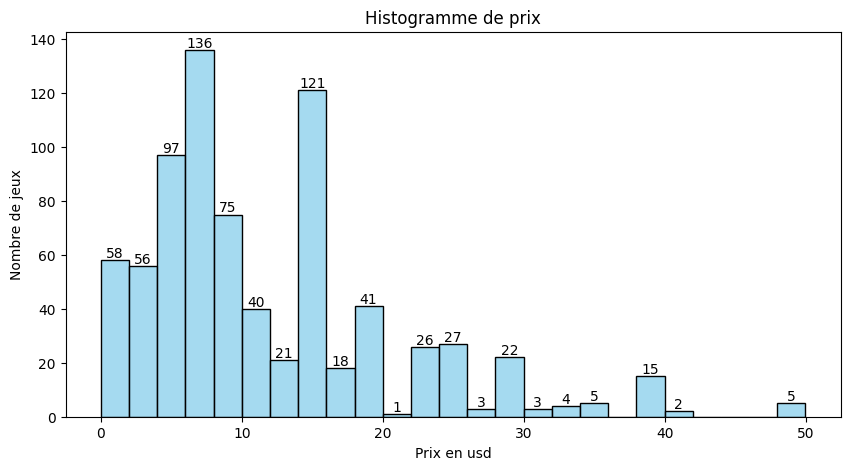

,prix
0,24.99
1,9.99
2,5.99
3,29.99
4,39.99
...,...
771,3.49
772,15.99
773,9.99
774,8.99


In [8]:
graph_prix('prix')